In [1]:
from pathlib import Path
from collections import Counter
import math
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

NOTEBOOK_DIR = Path.cwd()
DATASET_DIR = NOTEBOOK_DIR.parent / "dataset" if NOTEBOOK_DIR.name == "notebooks" else Path("../dataset")
if not DATASET_DIR.exists():
    DATASET_DIR = Path("../dataset").resolve()

TRAIN_DIR = DATASET_DIR / "Train"
TEST_DIR = DATASET_DIR / "Test"
META_DIR = DATASET_DIR / "Meta"
print("Dataset:", DATASET_DIR.resolve())
print("Train:", TRAIN_DIR.resolve())
print("Test:", TEST_DIR.resolve())
print("Meta:", META_DIR.resolve())

Dataset: D:\traffic-sign-recogonition\dataset
Train: D:\traffic-sign-recogonition\dataset\Train
Test: D:\traffic-sign-recogonition\dataset\Test
Meta: D:\traffic-sign-recogonition\dataset\Meta


In [2]:
def describe_tree(path, max_items=20):
    items = sorted(path.iterdir(), key=lambda item: (not item.is_dir(), item.name.lower()))
    for item in items[:max_items]:
        marker = "/" if item.is_dir() else ""
        print(f"{item.relative_to(DATASET_DIR)}{marker}")
    if len(items) > max_items:
        print(f"... {len(items) - max_items} more entries")

print("Top-level dataset entries:")
describe_tree(DATASET_DIR)
print("\nTest directory sample:")
describe_tree(TEST_DIR, max_items=12)
print("\nMeta directory entries:")
describe_tree(META_DIR, max_items=60)

train_df = pd.read_csv(DATASET_DIR / "Train.csv")
test_df = pd.read_csv(DATASET_DIR / "Test.csv")
meta_df = pd.read_csv(DATASET_DIR / "Meta.csv")

print("\nCSV shapes and columns:")
for name, frame in [("Train.csv", train_df), ("Test.csv", test_df), ("Meta.csv", meta_df)]:
    print(f"{name}: {frame.shape}, columns={list(frame.columns)}")
print("\nTrain.csv preview:")
display(train_df.head())
print("Test.csv preview:")
display(test_df.head())
print("Meta.csv preview:")
display(meta_df.head())

Top-level dataset entries:
Meta/
Test/
Train/
Meta.csv
Test.csv
Train.csv

Test directory sample:


Test\00000.png
Test\00001.png
Test\00002.png
Test\00003.png
Test\00004.png
Test\00005.png
Test\00006.png
Test\00007.png
Test\00008.png
Test\00009.png
Test\00010.png
Test\00011.png
... 12619 more entries

Meta directory entries:
Meta\.~lock.ClassesInformation.ods#
Meta\.~lock.ClassesInformationStrong.ods#
Meta\0.png
Meta\1.png
Meta\10.png
Meta\11.png
Meta\12.png
Meta\13.png
Meta\14.png
Meta\15.png
Meta\16.png
Meta\17.png
Meta\18.png
Meta\19.png
Meta\2.png
Meta\20.png
Meta\21.png
Meta\22.png
Meta\23.png
Meta\24.png
Meta\25.png
Meta\26.png
Meta\27.png
Meta\28.png
Meta\29.png
Meta\3.png
Meta\30.png
Meta\31.png
Meta\32.png
Meta\33.png
Meta\34.png
Meta\35.png
Meta\36.png
Meta\37.png
Meta\38.png
Meta\39.png
Meta\4.png
Meta\40.png
Meta\41.png
Meta\42.png
Meta\5.png
Meta\6.png
Meta\7.png
Meta\8.png
Meta\9.png

CSV shapes and columns:
Train.csv: (39209, 8), columns=['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']
Test.csv: (12630, 8), columns=['Width', 'Height', 'Ro

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


Test.csv preview:


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


Meta.csv preview:


,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22


In [3]:
train_classes = sorted(train_df["ClassId"].dropna().astype(int).unique())
test_classes = sorted(test_df["ClassId"].dropna().astype(int).unique())
meta_classes = sorted(meta_df["ClassId"].dropna().astype(int).unique())
class_ids = sorted(set(train_classes) | set(test_classes) | set(meta_classes))
expected_class_ids = list(range(min(class_ids), max(class_ids) + 1))
class_name_columns = [column for column in meta_df.columns if "name" in column.lower() or "label" in column.lower()]

print("Class IDs:", class_ids)
print("Number of classes:", len(class_ids))
print("Class IDs are continuous:", class_ids == expected_class_ids)
print("Train/test/meta class sets agree:", train_classes == test_classes == meta_classes)
print("Human-readable name or label columns in Meta.csv:", class_name_columns or "none")

class_map = meta_df.set_index("ClassId")[["ShapeId", "ColorId", "SignId"]].copy()
class_map["ClassName"] = [f"Class {class_id}" for class_id in class_map.index]
display(class_map.sort_index())

print("\nTrain path examples:", train_df["Path"].head(3).tolist())
print("Test path examples:", test_df["Path"].head(3).tolist())
print("Test labels are present in Test.csv:", "ClassId" in test_df.columns)
gt_file = TEST_DIR / "GT-final_test.csv"
gt_file_exists = gt_file.exists()
gt_file_empty = gt_file_exists and gt_file.stat().st_size == 0
print("Additional test-side label file exists:", gt_file_exists)
print("GT-final_test.csv is empty:", gt_file_empty)
if gt_file_exists and not gt_file_empty:
    print("GT-final_test.csv columns:", pd.read_csv(gt_file, nrows=0).columns.tolist())

Class IDs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42)]
Number of classes: 43
Class IDs are continuous: True
Train/test/meta class sets agree: True
Human-readable name or label columns in Meta.csv: none


,ShapeId,ColorId,SignId,ClassName
ClassId,,,,
0,1,0,3.29,Class 0
1,1,0,3.29,Class 1
2,1,0,3.29,Class 2
3,1,0,3.29,Class 3
4,1,0,3.29,Class 4
5,1,0,3.29,Class 5
6,1,3,3.3,Class 6
7,1,0,3.29,Class 7
8,1,0,3.29,Class 8



Train path examples: ['Train/20/00020_00000_00000.png', 'Train/20/00020_00000_00001.png', 'Train/20/00020_00000_00002.png']
Test path examples: ['Test/00000.png', 'Test/00001.png', 'Test/00002.png']
Test labels are present in Test.csv: True
Additional test-side label file exists: True
GT-final_test.csv is empty: True


,Train,Test,Train/Test ratio
ClassId,,,
0,210,60,3.500000
1,2220,720,3.083333
2,2250,750,3.000000
3,1410,450,3.133333
4,1980,660,3.000000
5,1860,630,2.952381
6,420,150,2.800000
7,1440,450,3.200000
8,1410,450,3.133333


Training images: 39,209
Test images: 12,630
Train images/class: min=210, max=2250, mean=911.84, median=600.00
Significantly underrepresented (< half the mean): [0, 6, 16, 19, 20, 21, 22, 24, 27, 29, 30, 32, 34, 36, 37, 39, 40, 41, 42]
Significantly overrepresented (> 1.5 times the mean): [1, 2, 3, 4, 5, 7, 8, 9, 10, 12, 13, 25, 38]


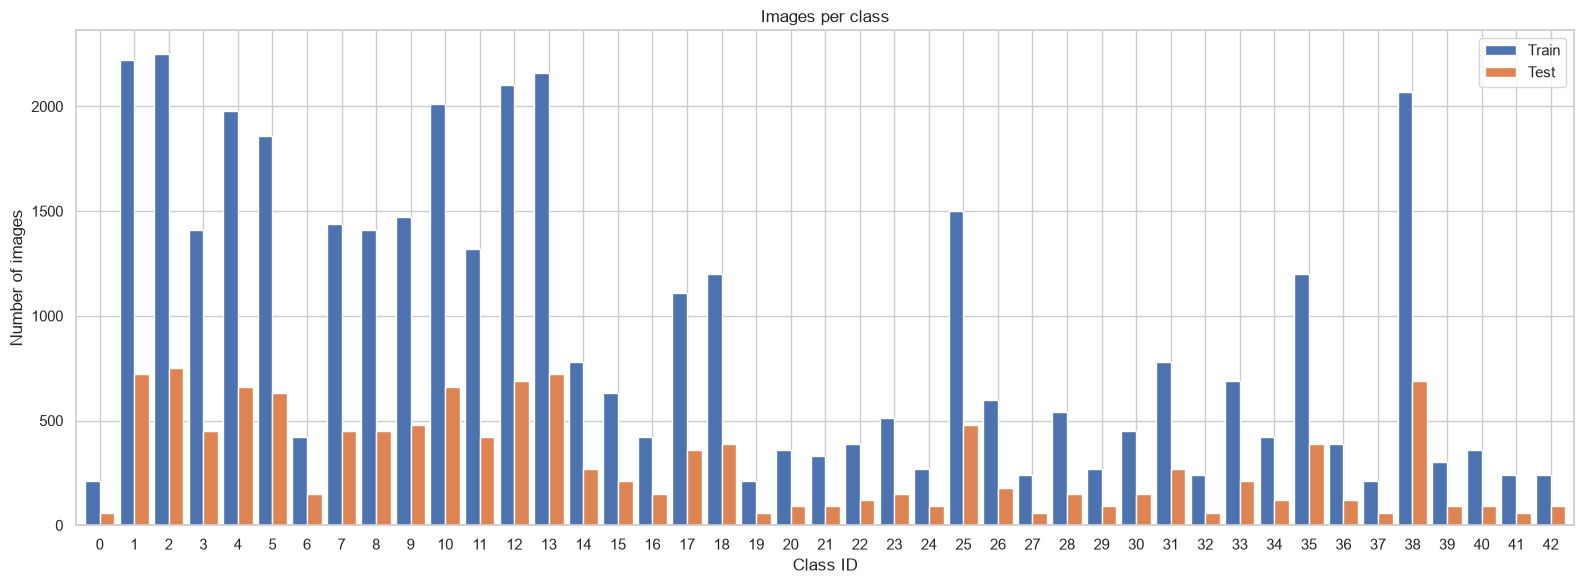

In [4]:
train_counts = train_df["ClassId"].value_counts().reindex(class_ids, fill_value=0).sort_index()
test_counts = test_df["ClassId"].value_counts().reindex(class_ids, fill_value=0).sort_index()
counts_df = pd.DataFrame({"Train": train_counts, "Test": test_counts})
counts_df["Train/Test ratio"] = counts_df["Train"] / counts_df["Test"]
display(counts_df)

train_min = int(train_counts.min())
train_max = int(train_counts.max())
train_mean = float(train_counts.mean())
train_median = float(train_counts.median())
underrepresented_ids = train_counts[train_counts < train_mean / 2].index.tolist()
overrepresented_ids = train_counts[train_counts > train_mean * 1.5].index.tolist()
print(f"Training images: {len(train_df):,}")
print(f"Test images: {len(test_df):,}")
print(f"Train images/class: min={train_min}, max={train_max}, mean={train_mean:.2f}, median={train_median:.2f}")
print("Significantly underrepresented (< half the mean):", underrepresented_ids)
print("Significantly overrepresented (> 1.5 times the mean):", overrepresented_ids)

plt.figure(figsize=(16, 6))
counts_df[["Train", "Test"]].plot(kind="bar", ax=plt.gca(), width=0.85)
plt.title("Images per class")
plt.xlabel("Class ID")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Image records inspected: 51839
Missing referenced images: train= 0 , test= 0
Unreadable referenced images: train= 0 , test= 0
Modes: {'RGB': 51839}
Formats: {'PNG': 51839}
Channels: {3: 51839}
Width range: 25 to 266
Height range: 25 to 232
Pixel range across train/test: 0 to 255
Most common dimensions:


,,Images
Width,Height,
31,31,523
30,30,503
32,32,486
33,33,486
29,29,470
35,35,465
36,36,456
30,31,447
38,38,443


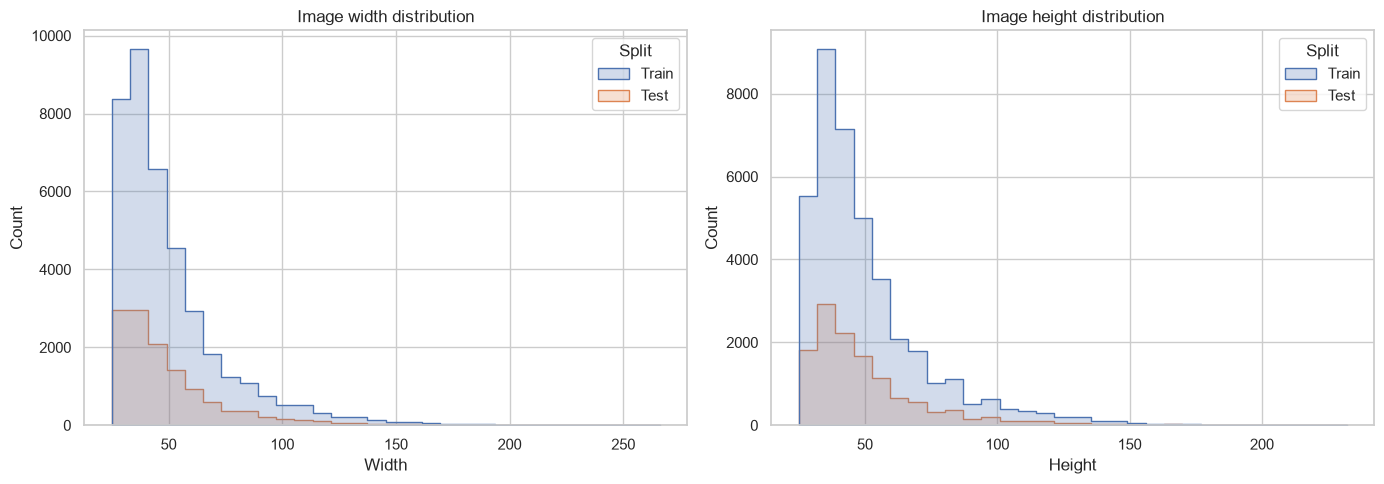

In [5]:
def inspect_images(frame, split_name):
    records = []
    missing = []
    unreadable = []
    for relative_path in frame["Path"]:
        path = DATASET_DIR / relative_path
        if not path.exists():
            missing.append(str(relative_path))
            continue
        try:
            with Image.open(path) as image:
                image.verify()
            with Image.open(path) as image:
                pixels = np.asarray(image)
                records.append({
                    "Split": split_name, "Path": str(relative_path),
                    "Width": image.width, "Height": image.height,
                    "Mode": image.mode, "Format": image.format,
                    "Channels": pixels.shape[2] if pixels.ndim == 3 else 1,
                    "PixelMin": int(pixels.min()), "PixelMax": int(pixels.max()),
                })
        except Exception as exc:
            unreadable.append({"Path": str(relative_path), "Error": repr(exc)})
    return pd.DataFrame(records), missing, unreadable

train_image_info, train_missing, train_unreadable = inspect_images(train_df, "Train")
test_image_info, test_missing, test_unreadable = inspect_images(test_df, "Test")
image_info = pd.concat([train_image_info, test_image_info], ignore_index=True)

print("Image records inspected:", len(image_info))
print("Missing referenced images: train=", len(train_missing), ", test=", len(test_missing))
print("Unreadable referenced images: train=", len(train_unreadable), ", test=", len(test_unreadable))
print("Modes:", image_info["Mode"].value_counts().to_dict())
print("Formats:", image_info["Format"].value_counts().to_dict())
print("Channels:", image_info["Channels"].value_counts().to_dict())
print("Width range:", int(image_info["Width"].min()), "to", int(image_info["Width"].max()))
print("Height range:", int(image_info["Height"].min()), "to", int(image_info["Height"].max()))
print("Pixel range across train/test:", int(image_info["PixelMin"].min()), "to", int(image_info["PixelMax"].max()))
print("Most common dimensions:")
display(image_info.groupby(["Width", "Height"]).size().sort_values(ascending=False).head(15).rename("Images").to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=image_info, x="Width", hue="Split", bins=30, element="step", ax=axes[0])
axes[0].set_title("Image width distribution")
sns.histplot(data=image_info, x="Height", hue="Split", bins=30, element="step", ax=axes[1])
axes[1].set_title("Image height distribution")
plt.tight_layout()
plt.show()

In [6]:
def filesystem_quality_report(directory, expected_image_suffixes={".png"}):
    files = [path for path in directory.rglob("*") if path.is_file()]
    unexpected = [str(path.relative_to(DATASET_DIR)) for path in files if path.suffix.lower() not in expected_image_suffixes]
    return files, unexpected

train_files, train_unexpected = filesystem_quality_report(TRAIN_DIR)
test_files, test_unexpected = filesystem_quality_report(TEST_DIR)
meta_files, meta_unexpected = filesystem_quality_report(META_DIR)

numeric_train_dirs = sorted([path for path in TRAIN_DIR.iterdir() if path.is_dir() and path.name.isdigit()], key=lambda path: int(path.name))
invalid_train_dirs = [path.name for path in TRAIN_DIR.iterdir() if path.is_dir() and not path.name.isdigit()]
empty_train_dirs = [path.name for path in numeric_train_dirs if not any(path.iterdir())]
filesystem_class_ids = [int(path.name) for path in numeric_train_dirs]
duplicate_train_filenames = train_df["Path"].map(lambda path: Path(path).name).duplicated(keep=False).sum()
duplicate_test_filenames = test_df["Path"].map(lambda path: Path(path).name).duplicated(keep=False).sum()
duplicate_train_paths = train_df["Path"].duplicated().sum()
duplicate_test_paths = test_df["Path"].duplicated().sum()

print("Train filesystem image files:", len(train_files))
print("Test filesystem image files:", len(test_files))
print("Meta filesystem files:", len(meta_files))
print("Unexpected Train file types:", train_unexpected)
print("Unexpected Test file types:", test_unexpected)
print("Unexpected Meta file types:", meta_unexpected)
print("Invalid non-numeric Train directories:", invalid_train_dirs)
print("Empty numeric Train directories:", empty_train_dirs)
print("Train directory IDs agree with CSV IDs:", filesystem_class_ids == train_classes)
print("Duplicate Train paths:", int(duplicate_train_paths), "; duplicate Test paths:", int(duplicate_test_paths))
print("Duplicate Train basenames (expected possible across class folders):", int(duplicate_train_filenames))
print("Duplicate Test basenames:", int(duplicate_test_filenames))

declared_paths = set(train_df["Path"]) | set(test_df["Path"]) | set(meta_df["Path"])
filesystem_image_paths = {path.relative_to(DATASET_DIR).as_posix() for path in DATASET_DIR.rglob("*.png")}
unlisted_images = sorted(filesystem_image_paths - declared_paths)
print("PNG files not referenced by the three metadata CSVs:", len(unlisted_images))
print("Examples:", unlisted_images[:10])

Train filesystem image files: 39209
Test filesystem image files: 12631
Meta filesystem files: 45
Unexpected Train file types: []
Unexpected Test file types: ['Test\\GT-final_test.csv']
Unexpected Meta file types: ['Meta\\.~lock.ClassesInformation.ods#', 'Meta\\.~lock.ClassesInformationStrong.ods#']
Invalid non-numeric Train directories: []
Empty numeric Train directories: []
Train directory IDs agree with CSV IDs: True
Duplicate Train paths: 0 ; duplicate Test paths: 0
Duplicate Train basenames (expected possible across class folders): 0
Duplicate Test basenames: 0


PNG files not referenced by the three metadata CSVs: 0
Examples: []


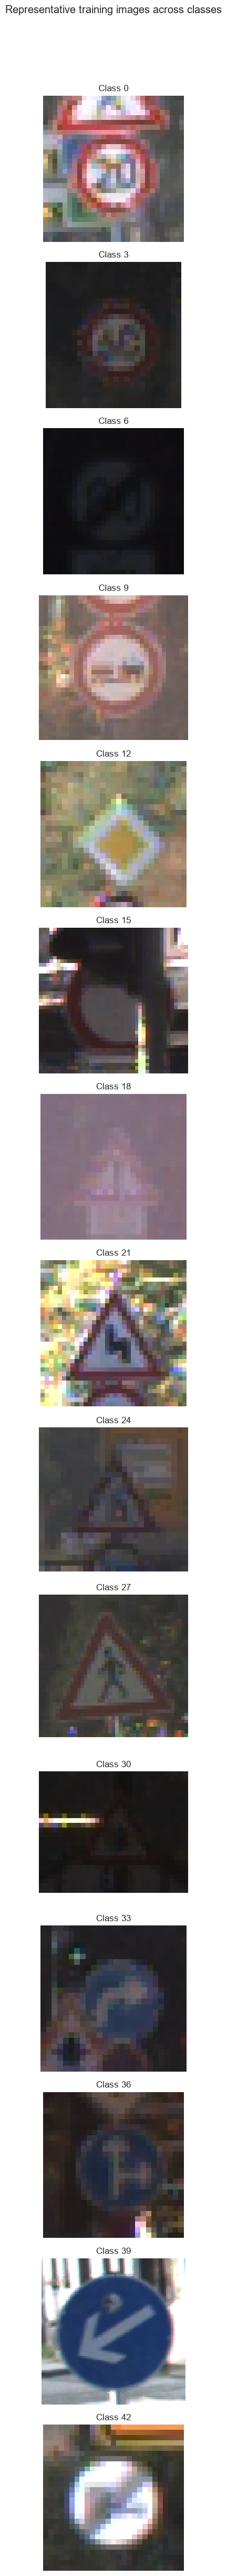

In [7]:
def display_grid(frame, selected_ids, samples_per_class=1, title=""):
    selected_rows = []
    for class_id in selected_ids:
        rows = frame[frame["ClassId"] == class_id].sort_values("Path").head(samples_per_class)
        selected_rows.extend(rows.to_dict("records"))
    columns = samples_per_class
    rows_count = math.ceil(len(selected_rows) / columns)
    fig, axes = plt.subplots(rows_count, columns, figsize=(3.2 * columns, 3.2 * rows_count), squeeze=False)
    for axis, row in zip(axes.flat, selected_rows):
        image_path = DATASET_DIR / row["Path"]
        with Image.open(image_path) as image:
            axis.imshow(image)
        class_id = int(row["ClassId"])
        axis.set_title(f"Class {class_id}")
        axis.axis("off")
    for axis in axes.flat[len(selected_rows):]:
        axis.axis("off")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

representative_ids = np.linspace(0, len(class_ids) - 1, 15, dtype=int)
representative_ids = [class_ids[index] for index in representative_ids]
display_grid(train_df, representative_ids, title="Representative training images across classes")

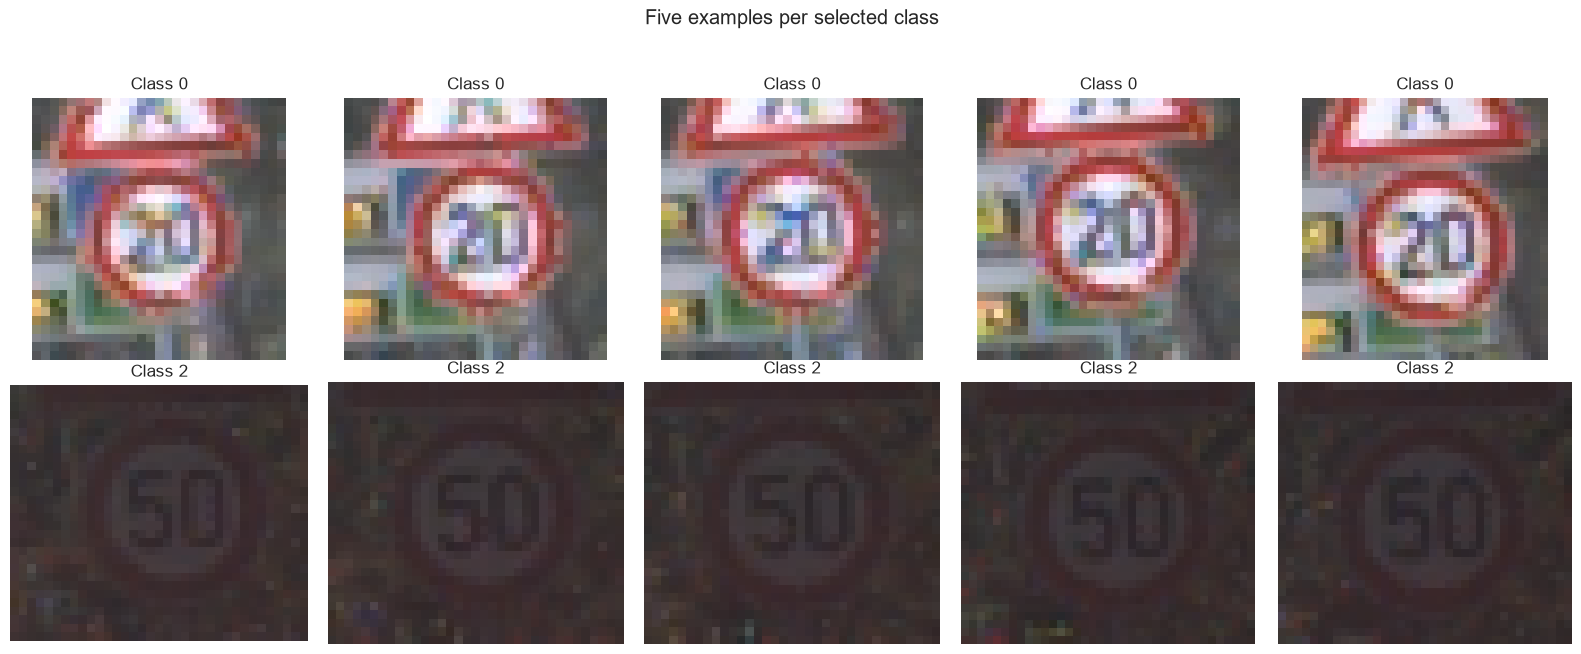

In [8]:
variation_ids = [int(train_counts.idxmin()), int(train_counts.idxmax()), 2]
variation_ids = list(dict.fromkeys(variation_ids))
display_grid(train_df, variation_ids, samples_per_class=5, title="Five examples per selected class")

In [9]:
all_referenced_images_readable = not train_missing and not test_missing and not train_unreadable and not test_unreadable
train_rgb = set(train_image_info["Mode"]) == {"RGB"}
test_rgb = set(test_image_info["Mode"]) == {"RGB"}
dataset_type = "A labeled multi-class traffic-sign image dataset with 43 continuous class IDs, CSV ROI metadata, class-level Meta.csv metadata, and PNG images. The local files strongly resemble the published GTSRB CSV/image schema, but provenance is not asserted from folder structure alone."

report_lines = [
    "### Concise findings",
    f"- **Dataset type:** {dataset_type}",
    f"- **Classes:** {len(class_ids)} continuous IDs, {class_ids[0]} through {class_ids[-1]}; human-readable class names are not present. Meta.csv provides ShapeId, ColorId, and SignId mappings.",
    f"- **Size:** {len(train_df):,} training images and {len(test_df):,} test images. Test labels are directly available in Test.csv, with GT-final_test.csv also present under Test/.",
    f"- **Images:** referenced train/test images are {'RGB' if train_rgb and test_rgb else 'not uniformly RGB'} PNG files; dimensions range from {int(image_info.Width.min())}x{int(image_info.Height.min())} to {int(image_info.Width.max())}x{int(image_info.Height.max())}, so resizing will be required for a fixed CNN input shape. Pixel values span {int(image_info.PixelMin.min())} to {int(image_info.PixelMax.max())}.",
    f"- **Imbalance:** training counts range from {train_min} to {train_max} images/class; mean={train_mean:.2f}, median={train_median:.2f}. Underrepresented by the notebook threshold are classes {underrepresented_ids}; overrepresented are classes {overrepresented_ids}.",
    f"- **Quality:** all CSV-referenced Train/Test images readable={all_referenced_images_readable}; missing Train/Test references={len(train_missing) + len(test_missing)}; unreadable Train/Test references={len(train_unreadable) + len(test_unreadable)}; empty numeric Train directories={empty_train_dirs or 'none'}.",
    "- **CNN implications:** preserve RGB channels, choose a fixed resize policy, use the ROI columns deliberately if cropping is later considered, and evaluate class-aware metrics or balancing because raw training counts are uneven. Any augmentation should be validated visually because signs contain orientation and geometry cues.",
    "- **Before training:** decide whether to use full images or ROI crops, document the class-ID-to-name limitation, and decide how to handle imbalance. No preprocessing, augmentation, or model training was performed here.",
]
print("\n".join(report_lines))

### Concise findings
- **Dataset type:** A labeled multi-class traffic-sign image dataset with 43 continuous class IDs, CSV ROI metadata, class-level Meta.csv metadata, and PNG images. The local files strongly resemble the published GTSRB CSV/image schema, but provenance is not asserted from folder structure alone.
- **Classes:** 43 continuous IDs, 0 through 42; human-readable class names are not present. Meta.csv provides ShapeId, ColorId, and SignId mappings.
- **Size:** 39,209 training images and 12,630 test images. Test labels are directly available in Test.csv, with GT-final_test.csv also present under Test/.
- **Images:** referenced train/test images are RGB PNG files; dimensions range from 25x25 to 266x232, so resizing will be required for a fixed CNN input shape. Pixel values span 0 to 255.
- **Imbalance:** training counts range from 210 to 2250 images/class; mean=911.84, median=600.00. Underrepresented by the notebook threshold are classes [0, 6, 16, 19, 20, 21, 22, 24, 27, 29